In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('ev_charging_bhubaneswar.csv')
df.head()

,Date,Day_of_Week,Hour,Month,Station_ID,Station_Name,Latitude,Longitude,Temperature,Humidity,...,Fast_Chargers,Slow_Chargers,Average_Session_Time,Historical_Demand,Battery_Level_Arrival,Queue_Length,Available_Ports,Occupied_Ports,Occupancy_Percentage,Target_Occupancy
0,01-08-2025,Friday,0,8,BBSR-01,IDCO Bhagabanpur Industrial Area,20.3552,85.791,31.2,85.0,...,2,3,40.1,36.9,31.2,0,5,0,2.0,6.6
1,01-08-2025,Friday,1,8,BBSR-01,IDCO Bhagabanpur Industrial Area,20.3552,85.791,29.7,82.1,...,2,3,45.1,36.9,32.5,0,5,0,6.6,2.9
2,01-08-2025,Friday,2,8,BBSR-01,IDCO Bhagabanpur Industrial Area,20.3552,85.791,30.0,86.7,...,2,3,45.6,36.9,13.9,0,5,0,2.9,9.6
3,01-08-2025,Friday,3,8,BBSR-01,IDCO Bhagabanpur Industrial Area,20.3552,85.791,29.2,82.9,...,2,3,36.8,36.9,30.4,0,5,0,9.6,12.2
4,01-08-2025,Friday,4,8,BBSR-01,IDCO Bhagabanpur Industrial Area,20.3552,85.791,26.6,90.8,...,2,3,40.5,36.9,33.1,0,4,1,12.2,17.6


In [3]:
df.isnull().sum()

Date                     0
Day_of_Week              0
Hour                     0
Month                    0
Station_ID               0
Station_Name             0
Latitude                 0
Longitude                0
Temperature              0
Humidity                 0
Rainfall                 0
Wind_Speed               0
Weather_Condition        0
Traffic_Level            0
Holiday                  0
Weekend                  0
Nearby_Event             0
Charging_Price           0
Number_of_Chargers       0
Fast_Chargers            0
Slow_Chargers            0
Average_Session_Time     0
Historical_Demand        0
Battery_Level_Arrival    0
Queue_Length             0
Available_Ports          0
Occupied_Ports           0
Occupancy_Percentage     0
Target_Occupancy         0
dtype: int64

In [5]:
print("Shape:", df.shape)

Shape: (131400, 29)


In [6]:
print(df.columns.tolist())

['Date', 'Day_of_Week', 'Hour', 'Month', 'Station_ID', 'Station_Name', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Weather_Condition', 'Traffic_Level', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Target_Occupancy']


In [7]:
print(df.dtypes)

Date                      object
Day_of_Week               object
Hour                       int64
Month                      int64
Station_ID                object
Station_Name              object
Latitude                 float64
Longitude                float64
Temperature              float64
Humidity                 float64
Rainfall                 float64
Wind_Speed               float64
Weather_Condition         object
Traffic_Level             object
Holiday                    int64
Weekend                    int64
Nearby_Event               int64
Charging_Price           float64
Number_of_Chargers         int64
Fast_Chargers              int64
Slow_Chargers              int64
Average_Session_Time     float64
Historical_Demand        float64
Battery_Level_Arrival    float64
Queue_Length               int64
Available_Ports            int64
Occupied_Ports             int64
Occupancy_Percentage     float64
Target_Occupancy         float64
dtype: object


In [8]:
display(df.describe(include='all'))

,Date,Day_of_Week,Hour,Month,Station_ID,Station_Name,Latitude,Longitude,Temperature,Humidity,...,Fast_Chargers,Slow_Chargers,Average_Session_Time,Historical_Demand,Battery_Level_Arrival,Queue_Length,Available_Ports,Occupied_Ports,Occupancy_Percentage,Target_Occupancy
count,131400,131400,131400.000000,131400.000000,131400,131400,131400.000000,131400.00000,131400.000000,131400.000000,...,131400.00000,131400.000000,131400.000000,131400.000000,131400.000000,131400.000000,131400.000000,131400.000000,131400.000000,131400.000000
unique,365,7,NaN,NaN,15,15,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,01-08-2025,Friday,NaN,NaN,BBSR-01,IDCO Bhagabanpur Industrial Area,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,360,19080,NaN,NaN,8760,8760,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,11.500000,6.526027,NaN,NaN,20.294253,85.81138,27.351724,69.157694,...,2.20000,2.600000,40.639659,39.168119,28.873971,0.045396,2.965008,1.834992,39.176887,39.178717
std,NaN,NaN,6.922213,3.447864,NaN,NaN,0.038315,0.03576,5.054397,10.609246,...,0.83267,0.611012,6.988126,24.632141,10.135760,0.336156,1.538198,1.412556,26.564631,26.562823
min,NaN,NaN,0.000000,1.000000,NaN,NaN,20.214500,85.71450,14.300000,46.300000,...,1.00000,2.000000,12.300000,2.000000,5.000000,0.000000,0.000000,0.000000,2.000000,2.000000
25%,NaN,NaN,5.750000,4.000000,NaN,NaN,20.268000,85.79100,24.600000,60.900000,...,2.00000,2.000000,35.900000,15.200000,22.000000,0.000000,2.000000,1.000000,14.400000,14.400000
50%,NaN,NaN,11.500000,7.000000,NaN,NaN,20.294600,85.82450,27.700000,67.600000,...,2.00000,3.000000,40.700000,39.700000,28.800000,0.000000,3.000000,2.000000,37.900000,37.900000
75%,NaN,NaN,17.250000,10.000000,NaN,NaN,20.315500,85.83900,30.900000,77.500000,...,3.00000,3.000000,45.400000,59.000000,35.700000,0.000000,4.000000,3.000000,60.300000,60.300000


In [9]:
print(df['Target_Occupancy'].describe())

count    131400.000000
mean         39.178717
std          26.562823
min           2.000000
25%          14.400000
50%          37.900000
75%          60.300000
max         100.000000
Name: Target_Occupancy, dtype: float64


In [12]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['Date', 'Day_of_Week', 'Station_ID', 'Station_Name', 'Weather_Condition', 'Traffic_Level']


In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nNumerical columns:")
print(numerical_cols.tolist())


Numerical columns:
['Hour', 'Month', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Target_Occupancy']


count    131400.000000
mean         39.178717
std          26.562823
min           2.000000
25%          14.400000
50%          37.900000
75%          60.300000
max         100.000000
Name: Target_Occupancy, dtype: float64


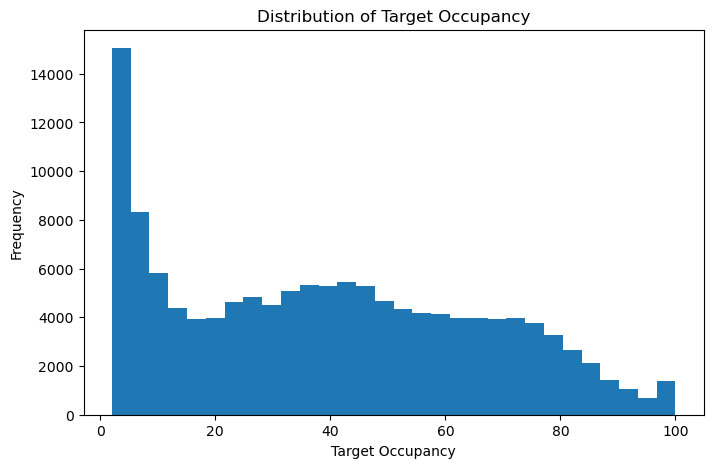

In [14]:
import matplotlib.pyplot as plt

print(df['Target_Occupancy'].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['Target_Occupancy'], bins=30)
plt.xlabel('Target Occupancy')
plt.ylabel('Frequency')
plt.title('Distribution of Target Occupancy')
plt.show()

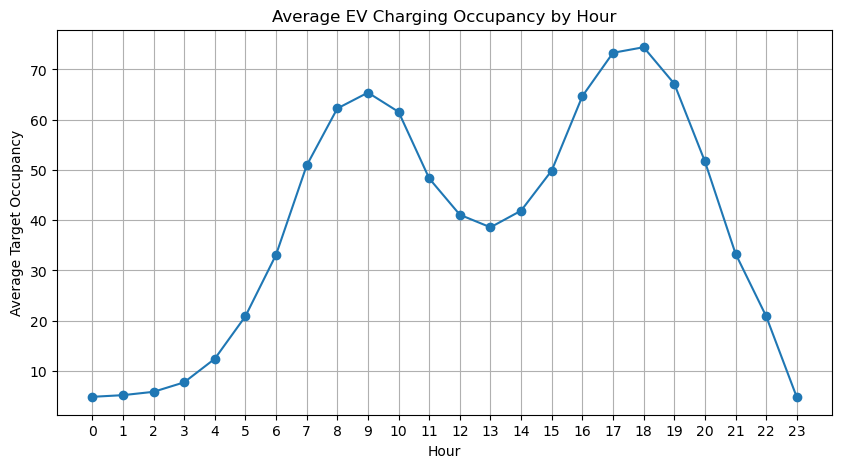

In [15]:
hourly_occupancy = df.groupby('Hour')['Target_Occupancy'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_occupancy.index, hourly_occupancy.values, marker='o')
plt.xlabel('Hour')
plt.ylabel('Average Target Occupancy')
plt.title('Average EV Charging Occupancy by Hour')
plt.xticks(range(24))
plt.grid()
plt.show()

Day_of_Week
Friday       40.920063
Monday       40.832922
Saturday     34.741752
Sunday       34.851832
Thursday     40.987837
Tuesday      41.013964
Wednesday    40.869161
Name: Target_Occupancy, dtype: float64


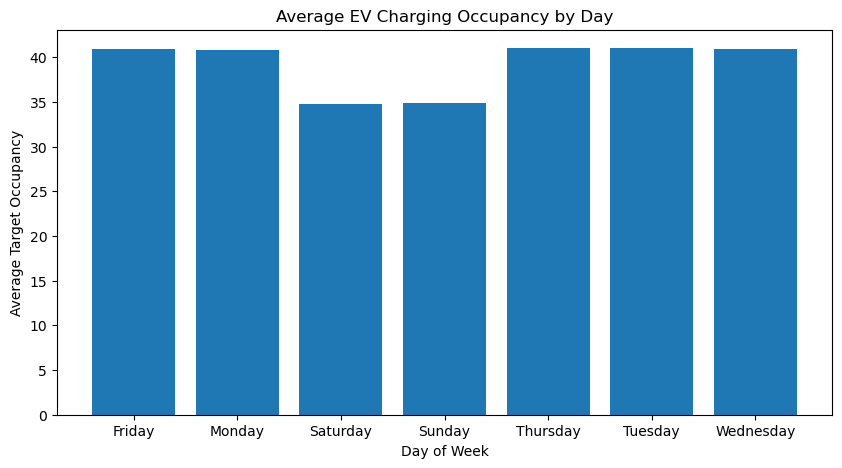

In [16]:
daily_occupancy = df.groupby('Day_of_Week')['Target_Occupancy'].mean()

print(daily_occupancy)

plt.figure(figsize=(10, 5))
plt.bar(daily_occupancy.index.astype(str), daily_occupancy.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Target Occupancy')
plt.title('Average EV Charging Occupancy by Day')
plt.show()

In [17]:
# Select numerical columns
numeric_data = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation
correlation = numeric_data.corr()

# Correlation with target
target_correlation = correlation['Target_Occupancy'].sort_values(ascending=False)

print(target_correlation)

Target_Occupancy         1.000000
Occupancy_Percentage     0.885195
Historical_Demand        0.837683
Occupied_Ports           0.815784
Charging_Price           0.402039
Hour                     0.385335
Queue_Length             0.220982
Nearby_Event             0.129431
Humidity                 0.084286
Rainfall                 0.067363
Wind_Speed               0.020338
Fast_Chargers            0.014578
Holiday                  0.010189
Month                   -0.004149
Number_of_Chargers      -0.042044
Longitude               -0.070946
Slow_Chargers           -0.091818
Latitude                -0.099892
Weekend                 -0.104133
Temperature             -0.127974
Battery_Level_Arrival   -0.185862
Average_Session_Time    -0.290631
Available_Ports         -0.777731
Name: Target_Occupancy, dtype: float64


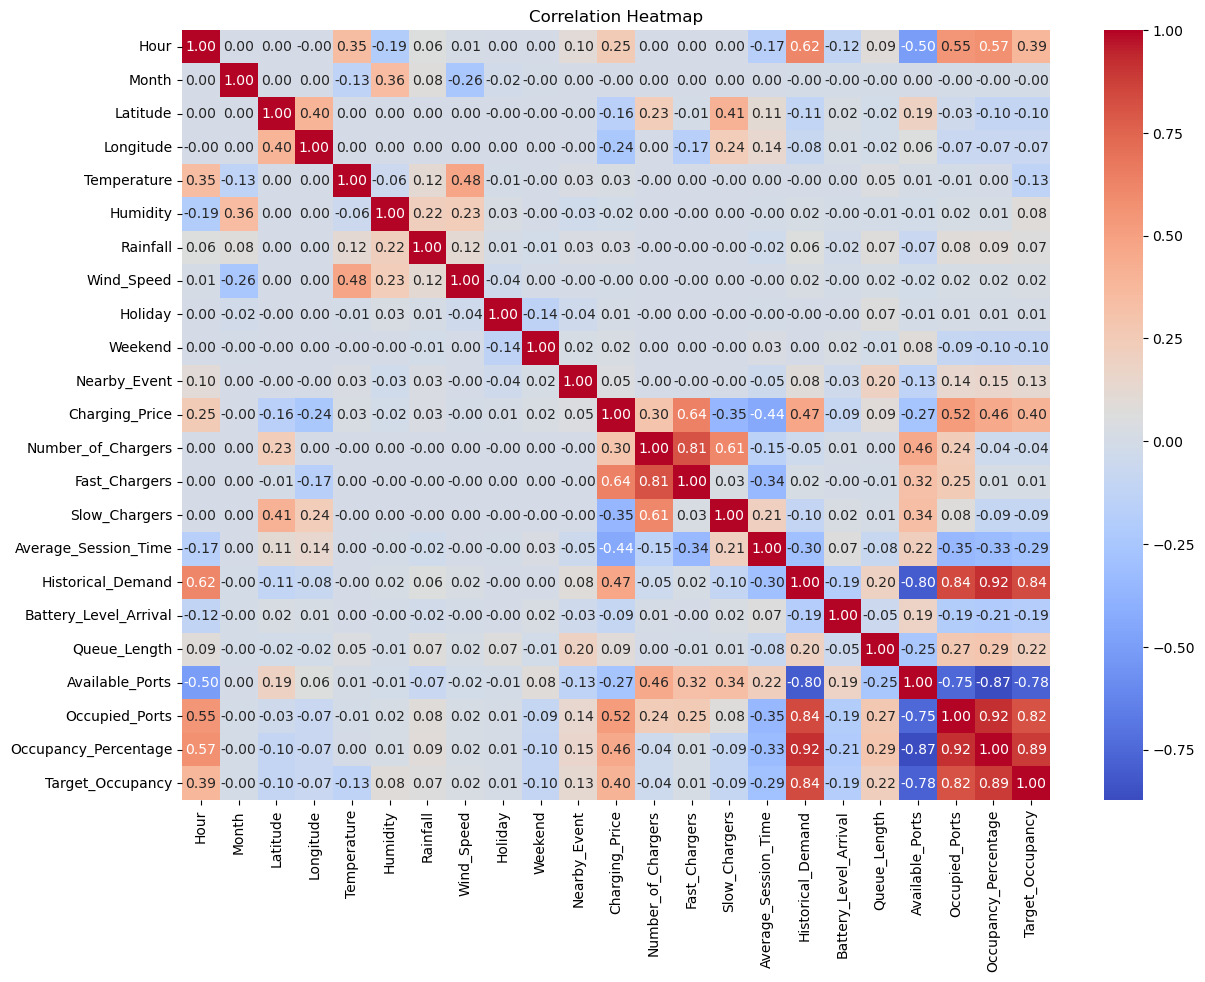

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [19]:
print(df.columns.tolist())

['Date', 'Day_of_Week', 'Hour', 'Month', 'Station_ID', 'Station_Name', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Weather_Condition', 'Traffic_Level', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Target_Occupancy']


In [20]:
print(df['Date'].head())
print(df['Date'].dtype)

0    01-08-2025
1    01-08-2025
2    01-08-2025
3    01-08-2025
4    01-08-2025
Name: Date, dtype: object
object


In [22]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [23]:
print(df['Date'].head())

0   2025-08-01
1   2025-08-01
2   2025-08-01
3   2025-08-01
4   2025-08-01
Name: Date, dtype: datetime64[ns]


In [24]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Year'] = df['Date'].dt.dayofyear
df['Week_of_Year'] = df['Date'].dt.isocalendar().week

In [25]:
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

In [26]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(131400, 34)
        Date Day_of_Week  Hour  Month Station_ID  \
0 2025-08-01      Friday     0      8    BBSR-01   
1 2025-08-01      Friday     1      8    BBSR-01   
2 2025-08-01      Friday     2      8    BBSR-01   
3 2025-08-01      Friday     3      8    BBSR-01   
4 2025-08-01      Friday     4      8    BBSR-01   

                       Station_Name  Latitude  Longitude  Temperature  \
0  IDCO Bhagabanpur Industrial Area   20.3552     85.791         31.2   
1  IDCO Bhagabanpur Industrial Area   20.3552     85.791         29.7   
2  IDCO Bhagabanpur Industrial Area   20.3552     85.791         30.0   
3  IDCO Bhagabanpur Industrial Area   20.3552     85.791         29.2   
4  IDCO Bhagabanpur Industrial Area   20.3552     85.791         26.6   

   Humidity  ...  Queue_Length  Available_Ports Occupied_Ports  \
0      85.0  ...             0                5              0   
1      82.1  ...             0                5              0   
2      86.7  ...             0       

In [28]:
print(df.columns.tolist())

['Date', 'Day_of_Week', 'Hour', 'Month', 'Station_ID', 'Station_Name', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Weather_Condition', 'Traffic_Level', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Target_Occupancy', 'Year', 'Day', 'Day_of_Year', 'Week_of_Year', 'Is_Weekend']


In [29]:
print(df.dtypes)

Date                     datetime64[ns]
Day_of_Week                      object
Hour                              int64
Month                             int32
Station_ID                       object
Station_Name                     object
Latitude                        float64
Longitude                       float64
Temperature                     float64
Humidity                        float64
Rainfall                        float64
Wind_Speed                      float64
Weather_Condition                object
Traffic_Level                    object
Holiday                           int64
Weekend                           int64
Nearby_Event                      int64
Charging_Price                  float64
Number_of_Chargers                int64
Fast_Chargers                     int64
Slow_Chargers                     int64
Average_Session_Time            float64
Historical_Demand               float64
Battery_Level_Arrival           float64
Queue_Length                      int64


In [30]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['Day_of_Week', 'Station_ID', 'Station_Name', 'Weather_Condition', 'Traffic_Level']


In [31]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

Numerical Columns:
['Hour', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Target_Occupancy', 'Is_Weekend']


In [32]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Date
1 Day_of_Week
2 Hour
3 Month
4 Station_ID
5 Station_Name
6 Latitude
7 Longitude
8 Temperature
9 Humidity
10 Rainfall
11 Wind_Speed
12 Weather_Condition
13 Traffic_Level
14 Holiday
15 Weekend
16 Nearby_Event
17 Charging_Price
18 Number_of_Chargers
19 Fast_Chargers
20 Slow_Chargers
21 Average_Session_Time
22 Historical_Demand
23 Battery_Level_Arrival
24 Queue_Length
25 Available_Ports
26 Occupied_Ports
27 Occupancy_Percentage
28 Target_Occupancy
29 Year
30 Day
31 Day_of_Year
32 Week_of_Year
33 Is_Weekend


In [33]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 365 unique values
Day_of_Week: 7 unique values
Hour: 24 unique values
Month: 12 unique values
Station_ID: 15 unique values
Station_Name: 15 unique values
Latitude: 14 unique values
Longitude: 15 unique values
Temperature: 246 unique values
Humidity: 491 unique values
Rainfall: 449 unique values
Wind_Speed: 212 unique values
Weather_Condition: 4 unique values
Traffic_Level: 3 unique values
Holiday: 2 unique values
Weekend: 2 unique values
Nearby_Event: 2 unique values
Charging_Price: 655 unique values
Number_of_Chargers: 5 unique values
Fast_Chargers: 4 unique values
Slow_Chargers: 3 unique values
Average_Session_Time: 522 unique values
Historical_Demand: 923 unique values
Battery_Level_Arrival: 621 unique values
Queue_Length: 8 unique values
Available_Ports: 8 unique values
Occupied_Ports: 8 unique values
Occupancy_Percentage: 981 unique values
Target_Occupancy: 981 unique values
Year: 2 unique values
Day: 31 unique values
Day_of_Year: 365 unique values
Week_of_Year: 52 unique va

In [34]:
X = df.drop('Target_Occupancy', axis=1)
y = df['Target_Occupancy']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (131400, 33)
y shape: (131400,)


In [35]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['Day_of_Week', 'Station_ID', 'Station_Name', 'Weather_Condition', 'Traffic_Level']


In [36]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded X shape:", X_encoded.shape)

Encoded X shape: (131400, 67)


In [37]:
print(X_encoded.head())
print(X_encoded.dtypes)

        Date  Hour  Month  Latitude  Longitude  Temperature  Humidity  \
0 2025-08-01     0      8   20.3552     85.791         31.2      85.0   
1 2025-08-01     1      8   20.3552     85.791         29.7      82.1   
2 2025-08-01     2      8   20.3552     85.791         30.0      86.7   
3 2025-08-01     3      8   20.3552     85.791         29.2      82.9   
4 2025-08-01     4      8   20.3552     85.791         26.6      90.8   

   Rainfall  Wind_Speed  Holiday  ...  \
0       0.0        13.5        0  ...   
1       0.0        10.3        0  ...   
2       0.0        11.1        0  ...   
3       0.0        12.8        0  ...   
4       0.0        15.4        0  ...   

   Station_Name_Pahala NH-16 (Apex Institute)  Station_Name_Patia Infocity  \
0                                       False                        False   
1                                       False                        False   
2                                       False                        False   
3 

In [38]:
print("Missing values:", X_encoded.isnull().sum().sum())

Missing values: 0


In [49]:
# Check datetime columns
datetime_cols = X_train.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

print("Datetime columns:")
print(datetime_cols.tolist())

Datetime columns:
['Date']


In [50]:
# Remove target and Date
X = df.drop(columns=['Target_Occupancy', 'Date'])

# Target
y = df['Target_Occupancy']

print("X columns:")
print(X.columns.tolist())

X columns:
['Day_of_Week', 'Hour', 'Month', 'Station_ID', 'Station_Name', 'Latitude', 'Longitude', 'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Weather_Condition', 'Traffic_Level', 'Holiday', 'Weekend', 'Nearby_Event', 'Charging_Price', 'Number_of_Chargers', 'Fast_Chargers', 'Slow_Chargers', 'Average_Session_Time', 'Historical_Demand', 'Battery_Level_Arrival', 'Queue_Length', 'Available_Ports', 'Occupied_Ports', 'Occupancy_Percentage', 'Year', 'Day', 'Day_of_Year', 'Week_of_Year', 'Is_Weekend']


In [51]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Categorical columns encoded:")
print(categorical_cols.tolist())

print("X shape:", X_encoded.shape)

Categorical columns encoded:
['Day_of_Week', 'Station_ID', 'Station_Name', 'Weather_Condition', 'Traffic_Level']
X shape: (131400, 66)


In [52]:
print("Datetime columns remaining:")
print(X_encoded.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist())

Datetime columns remaining:
[]


In [53]:
print("Object columns remaining:")
print(X_encoded.select_dtypes(include=['object']).columns.tolist())

Object columns remaining:
[]


In [54]:
split_index = int(len(X_encoded) * 0.8)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (105120, 66)
X_test: (26280, 66)
y_train: (105120,)
y_test: (26280,)


In [55]:
print(X_train.dtypes.value_counts())

bool       39
int64      11
float64    11
int32       4
UInt32      1
Name: count, dtype: int64


In [56]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [57]:
y_pred_lr = lr_model.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
MAE : 8.729539829583063
RMSE: 11.211699341828695
R²  : 0.8137129844873422


In [59]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

print(comparison.head(10))

   Actual  Predicted
0    11.1  21.466736
1     3.6  27.067143
2    10.8  21.479525
3     2.0  26.101753
4    16.7  20.654610
5    32.6  30.694743
6    33.9  41.696603
7    55.3  42.778911
8    75.1  55.223310
9    66.7  71.313654


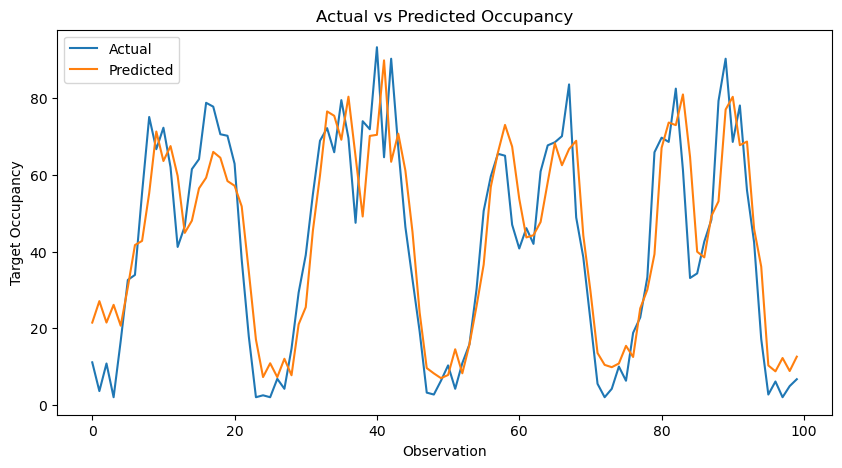

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred_lr[:100], label='Predicted')

plt.xlabel('Observation')
plt.ylabel('Target Occupancy')
plt.title('Actual vs Predicted Occupancy')
plt.legend()
plt.show()

In [66]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [67]:
y_pred_rf = rf_model.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 5.228758162634296
RMSE: 6.809500851274665
R²  : 0.931282040367181


In [69]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(model_comparison)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  8.729540  11.211699  0.813713
1      Random Forest  5.228758   6.809501  0.931282


In [70]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
21,Occupancy_Percentage,0.778387
0,Hour,0.153729
16,Historical_Demand,0.029416
2,Latitude,0.004325
64,Traffic_Level_Low,0.003593
11,Charging_Price,0.003081
3,Longitude,0.002556
8,Holiday,0.001877
4,Temperature,0.001688
15,Average_Session_Time,0.001592


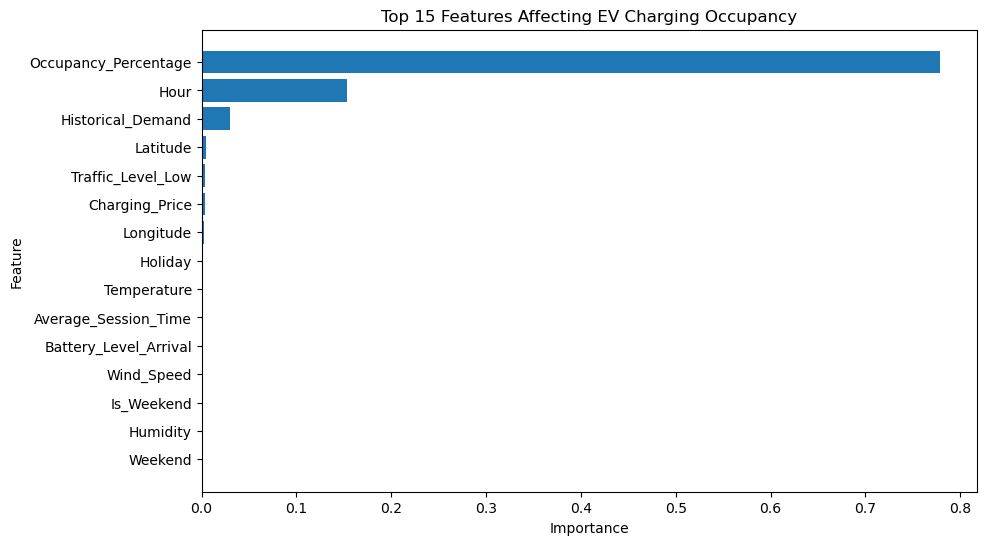

In [71]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features Affecting EV Charging Occupancy')

plt.show()

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

In [73]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [74]:
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [75]:
y_pred_gb = gb_model.predict(X_test)

In [76]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
MAE : 5.388583823238214
RMSE: 7.053850287284967
R²  : 0.9262618606657232


In [77]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

display(model_comparison.sort_values('R2 Score', ascending=False))

,Model,MAE,RMSE,R2 Score
1,Random Forest,5.228758,6.809501,0.931282
2,Gradient Boosting,5.388584,7.053850,0.926262
0,Linear Regression,8.729540,11.211699,0.813713


In [78]:
best_model_result = model_comparison.sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]

print("Best Model:", best_model_result['Model'])
print("R² Score:", best_model_result['R2 Score'])
print("MAE:", best_model_result['MAE'])
print("RMSE:", best_model_result['RMSE'])

Best Model: Random Forest
R² Score: 0.931282040367181
MAE: 5.228758162634296
RMSE: 6.809500851274665


In [79]:
print(best_model_result['Model'])

Random Forest


In [80]:
print("Best Model:", best_model_result['Model'])

Best Model: Random Forest


In [85]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,
    cv=2,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}


In [86]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

In [87]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest
MAE : 5.267826581978672
RMSE: 6.891104247729346
R²  : 0.9296251732355281


In [88]:
comparison_tuning = pd.DataFrame({
    'Model': [
        'Random Forest Before Tuning',
        'Random Forest After Tuning'
    ],
    'MAE': [
        mae_rf,
        mae_tuned
    ],
    'RMSE': [
        rmse_rf,
        rmse_tuned
    ],
    'R2 Score': [
        r2_rf,
        r2_tuned
    ]
})

display(comparison_tuning)

,Model,MAE,RMSE,R2 Score
0,Random Forest Before Tuning,5.228758,6.809501,0.931282
1,Random Forest After Tuning,5.267827,6.891104,0.929625


In [89]:
best_model = random_search.best_estimator_

y_pred_final = best_model.predict(X_test)

In [90]:
comparison = pd.DataFrame({
    'Actual Occupancy': y_test.values,
    'Predicted Occupancy': y_pred_final
})

display(comparison.head(20))

,Actual Occupancy,Predicted Occupancy
0,11.1,4.119434
1,3.6,5.035504
2,10.8,4.868873
3,2.0,6.749684
4,16.7,15.588289
5,32.6,29.733367
6,33.9,61.293930
7,55.3,61.195962
8,75.1,74.276735
9,66.7,74.025458


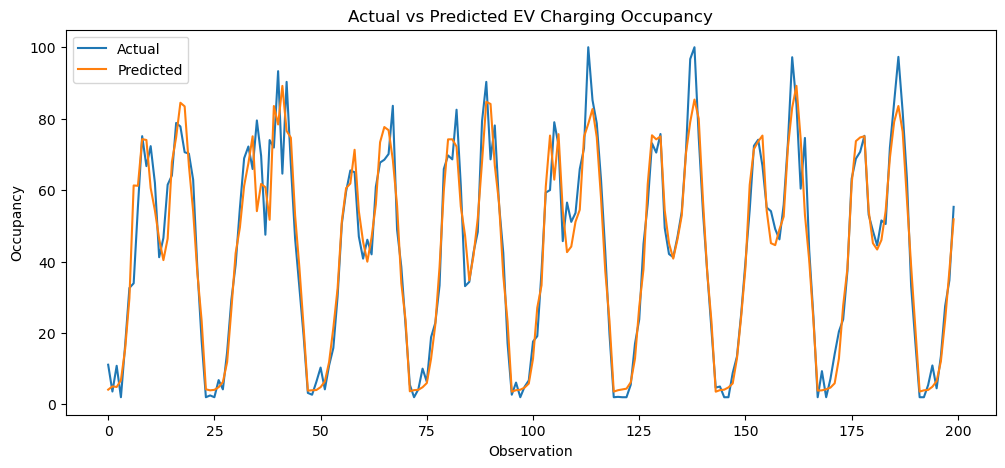

In [91]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    y_pred_final[:200],
    label='Predicted'
)

plt.xlabel('Observation')
plt.ylabel('Occupancy')
plt.title('Actual vs Predicted EV Charging Occupancy')
plt.legend()
plt.show()

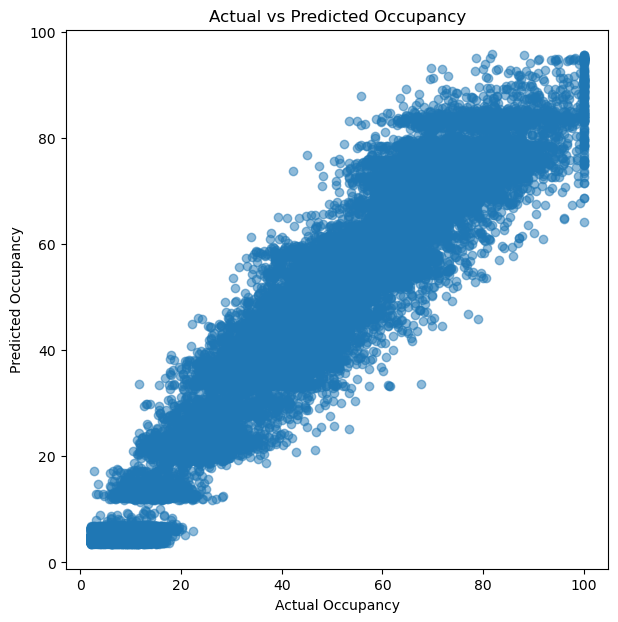

In [92]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred_final, alpha=0.5)

plt.xlabel('Actual Occupancy')
plt.ylabel('Predicted Occupancy')
plt.title('Actual vs Predicted Occupancy')

plt.show()

In [93]:
final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("Final Model Performance")
print("-----------------------")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Model Performance
-----------------------
MAE : 5.267826581978672
RMSE: 6.891104247729346
R²  : 0.9296251732355281


In [94]:
residuals = y_test.values - y_pred_final

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[  6.98056578  -1.43550373   5.93112723  -4.74968374   1.11171121
   2.86663297 -27.39392967  -5.8959619    0.82326502  -7.32545785]


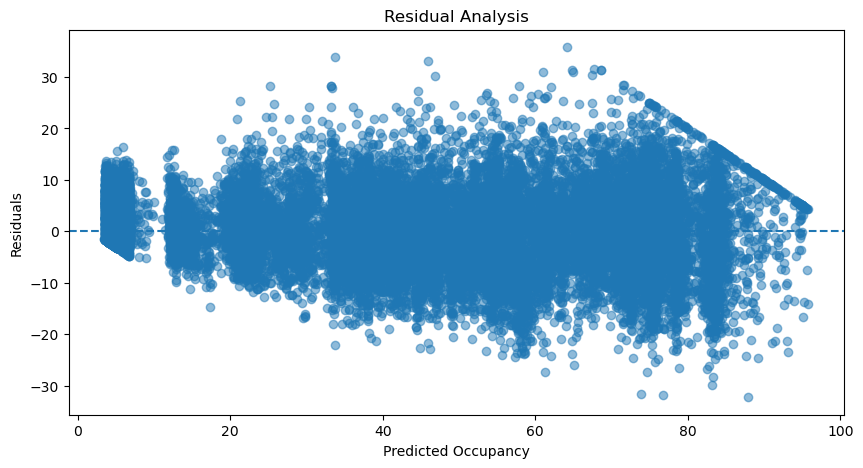

In [95]:
plt.figure(figsize=(10, 5))

plt.scatter(y_pred_final, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Occupancy')
plt.ylabel('Residuals')
plt.title('Residual Analysis')

plt.show()

In [96]:
final_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

final_importance = final_importance.sort_values(
    by='Importance',
    ascending=False
)

display(final_importance.head(15))

,Feature,Importance
21,Occupancy_Percentage,0.796679
0,Hour,0.156726
16,Historical_Demand,0.027736
64,Traffic_Level_Low,0.003307
2,Latitude,0.003235
3,Longitude,0.001934
26,Is_Weekend,0.001212
9,Weekend,0.001092
11,Charging_Price,0.000994
8,Holiday,0.000833


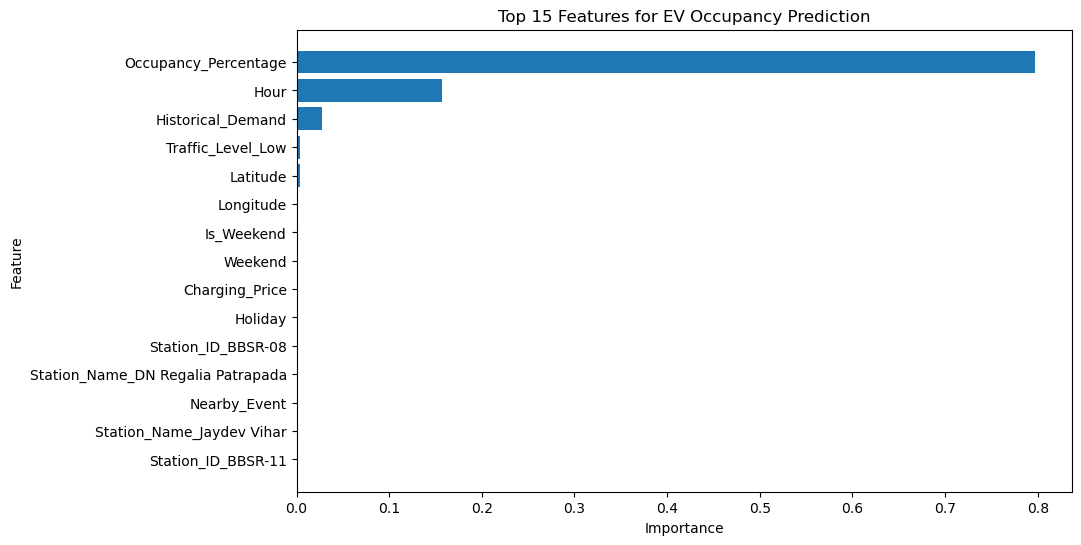

In [97]:
top_features = final_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features for EV Occupancy Prediction')

plt.show()

In [98]:
import joblib

joblib.dump(best_model, 'ev_charging_occupancy_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [99]:
import os

print(os.path.getsize('ev_charging_occupancy_model.pkl'), "bytes")

13260177 bytes


In [100]:
loaded_model = joblib.load(
    'ev_charging_occupancy_model.pkl'
)

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Predictions:")
print(test_prediction)

Predictions:
[ 4.11943422  5.03550373  4.86887277  6.74968374 15.58828879]


In [101]:
print("Number of features:", len(X_train.columns))

print("\nFeatures required by the model:")
for i, col in enumerate(X_train.columns, start=1):
    print(i, col)

Number of features: 66

Features required by the model:
1 Hour
2 Month
3 Latitude
4 Longitude
5 Temperature
6 Humidity
7 Rainfall
8 Wind_Speed
9 Holiday
10 Weekend
11 Nearby_Event
12 Charging_Price
13 Number_of_Chargers
14 Fast_Chargers
15 Slow_Chargers
16 Average_Session_Time
17 Historical_Demand
18 Battery_Level_Arrival
19 Queue_Length
20 Available_Ports
21 Occupied_Ports
22 Occupancy_Percentage
23 Year
24 Day
25 Day_of_Year
26 Week_of_Year
27 Is_Weekend
28 Day_of_Week_Monday
29 Day_of_Week_Saturday
30 Day_of_Week_Sunday
31 Day_of_Week_Thursday
32 Day_of_Week_Tuesday
33 Day_of_Week_Wednesday
34 Station_ID_BBSR-02
35 Station_ID_BBSR-03
36 Station_ID_BBSR-04
37 Station_ID_BBSR-05
38 Station_ID_BBSR-06
39 Station_ID_BBSR-07
40 Station_ID_BBSR-08
41 Station_ID_BBSR-09
42 Station_ID_BBSR-10
43 Station_ID_BBSR-11
44 Station_ID_BBSR-12
45 Station_ID_BBSR-13
46 Station_ID_BBSR-14
47 Station_ID_BBSR-15
48 Station_Name_Bhubaneswar Railway Station
49 Station_Name_CRP Square / Krishna Plaza
50 S

In [102]:
print("Final model expects:", best_model.n_features_in_, "features")

Final model expects: 66 features


In [103]:
model_data = {
    'model': best_model,
    'features': X_train.columns.tolist()
}

joblib.dump(
    model_data,
    'ev_charging_occupancy_model.pkl'
)

print("Model and feature names saved successfully!")

Model and feature names saved successfully!
